## Fraud Detection Part 1: Anomaly Detection with IsolationForest (Synthetic Data)

> **Synthetic data.** Every row in `anomaly.csv`, including the `is_fraud` label, is generated by `generate_data.py`. The label comes from a logistic risk model written in that script, so a model that scores well here is partly recovering a rule we planted. This notebook is an investigation of **method**: diagnosing a broken pipeline, testing whether the data contains any learnable signal, and deciding whether an unsupervised model is the right tool. It is not evidence about real-world fraud patterns. Part 2 applies the conclusions to real transaction data.


### Loading the data

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("anomaly.csv")
df.head(5)

,transaction_amount,account_age_days,num_prev_transactions,location_distance_km,hour_of_day,is_weekend,device_type,is_fraud
0,56.312171,2837,23,2.895882,19,0,mobile,0
1,361.214572,2766,17,NaN,10,1,desktop,0
2,158.009483,2759,20,NaN,18,0,mobile,0
3,109.553106,2028,20,9.483121,1,0,mobile,0
4,20.354984,2828,19,19.581347,5,1,mobile,0


In [3]:
df.shape

(500000, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   transaction_amount     460041 non-null  float64
 1   account_age_days       500000 non-null  int64  
 2   num_prev_transactions  500000 non-null  int64  
 3   location_distance_km   459930 non-null  float64
 4   hour_of_day            500000 non-null  int64  
 5   is_weekend             500000 non-null  int64  
 6   device_type            500000 non-null  str    
 7   is_fraud               500000 non-null  int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 30.5 MB


### Missing values

In [5]:
df.isna().sum()

transaction_amount       39959
account_age_days             0
num_prev_transactions        0
location_distance_km     40070
hour_of_day                  0
is_weekend                   0
device_type                  0
is_fraud                     0
dtype: int64

In [6]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0] * 100

location_distance_km    8.0140
transaction_amount      7.9918
dtype: float64

Missing value not negligible so must be handled. This is done during Preprocessing using median strategy since data is heavily skewed

### Visualisations

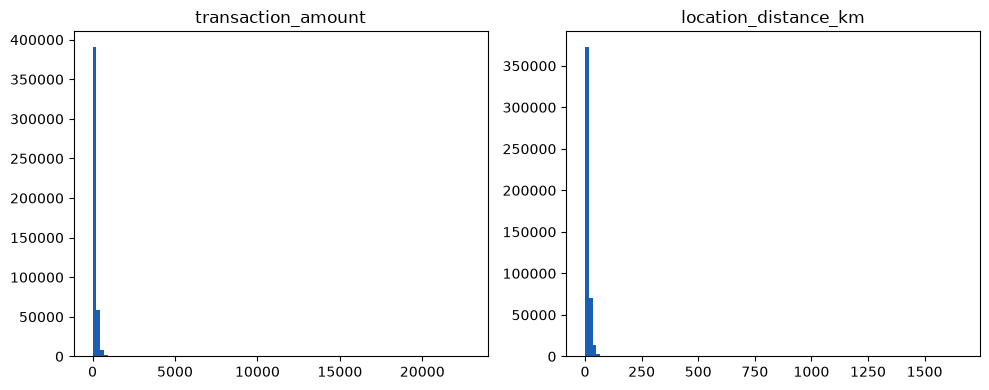

In [7]:
cols = ['transaction_amount', 'location_distance_km']

df[cols].hist(bins = 100, figsize = (10, 4), color = '#1a5fb4', grid = False )
plt.tight_layout()
plt.show()

Most of the data is tightly concentrated at a lower range while a small number of points stretch far into longer tails. The extreme values are not just outliers. They are exactly where anomalies tend to hide. We use IsolationForest because instead of modelling the dense region, the focus is on how easily a point can be separated. Points in the main cluster that are normal require many splits to isolate. But extreme tail values or potential anomalies can be isolated in just a few splits. That shorter path length becomes the signal, and that's what is used to flag high risk anomalies.

### Preprocessing Pipeline


In [8]:
#import libraries
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

In [9]:
# Separate numeric features
numeric_cols = [
    'transaction_amount',
    'account_age_days',
    'num_prev_transactions',
    'location_distance_km',
    'hour_of_day'
]

In [10]:
# Separate categorical features
categorical_cols = ['device_type', 'is_weekend']

In [11]:
# Numerical pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', RobustScaler())
])

In [12]:
# Categorical pipeline
categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown = 'ignore'))
])

In [13]:
# Combine all together
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

Build the full pipeline with IsolationForest.

Note on `contamination`: this parameter does **not** change how the trees are built or how anomaly scores are computed. It only picks the threshold on those scores that separates the `-1` (anomaly) and `1` (normal) labels returned by `.predict()`. Set it too high and the model mechanically flags that fraction of rows regardless of whether they are unusual. Here we set it to the true fraud prevalence (~1.50%) so the flagged count matches reality and the classification report is interpretable.

In [14]:
from sklearn.ensemble import IsolationForest

In [15]:
# contamination = expected fraction of anomalies in the data.
# It sets the score cut-off, so it must match the real anomaly rate, not a guess.
# Observed fraud prevalence in this dataset is 7492 / 500000 = 0.0150, so we use that.
# (contamination = 0.5 would force the model to flag half of every transaction as fraud.)
CONTAMINATION = 0.0150

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', IsolationForest(
        n_estimators = 500,
        contamination = CONTAMINATION,  # pyright: ignore[reportArgumentType]  (sklearn infers 'str' from the 'auto' default; floats are valid)
        random_state = 42
    ))
])

### Train the model

In [16]:
#Split into features (X) and target (y)
X = df.drop(columns = ['is_fraud']).copy()
y = df['is_fraud'].copy()

pipeline.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['transaction_amount','account_age_days','num_prev_transactions',..., 'hour_of_day','is_weekend','device_type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically

### Model Predictions

**Note: in-sample scoring.** IsolationForest is fitted and scored on the same rows, and there is no held-out set. For an unsupervised model that never sees the labels this is less of a problem than for a supervised one, but the evaluation metrics below are still in-sample and probably slightly optimistic. A production setup would fit on a past period and score future transactions (see Part 2).

IsolationForest returns -1 for anomaly and 1 for normal

In [17]:
# Raw predictions (-1 = anomaly, 1 = normal)
preds = pipeline.predict(X)

# Convert anomalies to 1, normal to 0
binary_preds = (pd.Series(preds) == -1).astype(int)

#get anomaly scores (score of how normal a point is, higher values more normal, lower values  more anomalies)
scores = pipeline.decision_function(X)

### Model Evaluation

#### Why these metrics: the dataset is imbalanced

Only **1.5%** of transactions are fraud (7,492 of 500,000), and that shapes which metrics are meaningful:

| Metric | Effect of imbalance | How we use it |
|---|---|---|
| **Accuracy** | Misleading. A model that flags nothing scores 98.5% | Not used |
| **Classification report, normal row / weighted average** | Dominated by the 98.5% normal class, so it looks good whatever the model does | Read the **fraud row** only |
| **ROC-AUC** | Flattering. The false positive rate is divided by ~492,000 normal transactions, so thousands of false alerts barely move it | Secondary |
| **Precision–recall curve / Average Precision (AP)** | Honest. Precision counts false alerts directly against frauds caught | **Primary metric** |
| **Fraud-class precision and recall at a threshold** | Honest, and maps to operations: alert workload vs fraud missed | Alongside AP |

**AP depends on the base rate.** A random model scores AP equal to the fraud rate (0.015 here), so we report AP as **lift over the base rate** rather than as an absolute number.

IsolationForest never sees the labels, so the imbalance does not affect training here, only evaluation. A supervised model would need class weights, and its validation and test sets must keep the real fraud rate (no resampling).


#### 1. Performance at the chosen threshold

Classification Report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y, binary_preds))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99    492508
           1       0.06      0.06      0.06      7492

    accuracy                           0.97    500000
   macro avg       0.52      0.52      0.52    500000
weighted avg       0.97      0.97      0.97    500000



**Reading the classification report.** The 97% accuracy is misleading. A model that flagged nothing would score 98.5%, because 98.5% of transactions are normal. The fraud row (class `1`) is the one that matters: precision and recall are both about 0.06. Only about 6% of flagged transactions are fraud, and only about 6% of all fraud is caught.

Precision and recall are equal by construction. `contamination` is set to the fraud rate, so the model flags almost exactly as many rows (7,500) as there are frauds (7,492). With equal counts, precision = TP / flagged ≈ TP / actual fraud = recall. These numbers describe one arbitrary threshold, not the model's ranking ability. The next section evaluates that ranking across all thresholds.

Confusion matrix AFTER anomaly conversion (flagged as anomaly = predicted fraud)

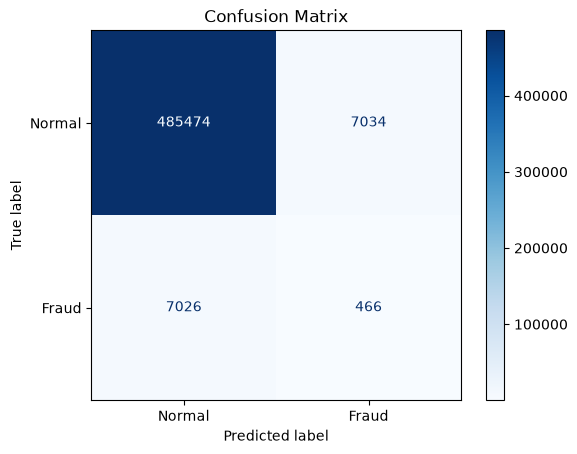

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y, binary_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Normal', 'Fraud'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


**Reading the confusion matrix.** Rows are the true label (`is_fraud`). Columns are the model's prediction, where "Fraud" means flagged as an anomaly. Of 7,500 flagged transactions, 466 are fraud (true positives) and 7,034 are normal (false positives). 7,026 frauds are missed (false negatives).

In operational terms:
- **False alerts per fraud caught:** 7,034 false positives ÷ 466 true positives ≈ **15**. An analyst team reviewing these alerts would clear about 15 normal transactions for every fraud found.
- **Fraud missed:** 7,026 ÷ 7,492 total frauds ≈ **94%** of fraud goes undetected.

This is not usable as a production alerting rule.


#### 2. Performance across all thresholds

Precision–Recall curve and Average Precision.

Unlike the classification report, this does **not** depend on `contamination`. It evaluates the ranking quality of the raw anomaly scores against the true labels. If this is near the fraud base rate (~0.015), the scores carry no useful fraud signal.

Average Precision: 0.033579880569579765
Contamination threshold: precision = 0.062, recall = 0.062


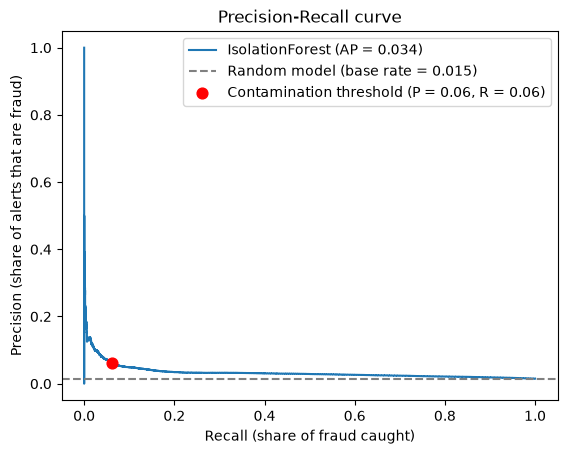

In [20]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

# Negate the scores: decision_function is high for normal points, but the PR curve expects high = fraud
precision, recall, thresholds = precision_recall_curve(y, -scores)
ap = average_precision_score(y, -scores)

# Operating point chosen by contamination (the threshold behind the classification report)
op_precision = precision_score(y, binary_preds)
op_recall = recall_score(y, binary_preds)

print("Average Precision:", ap)
print(f"Contamination threshold: precision = {op_precision:.3f}, recall = {op_recall:.3f}")

plt.plot(recall, precision, label = f'IsolationForest (AP = {ap:.3f})')
plt.axhline(y.mean(), color = 'grey', linestyle = '--', label = f'Random model (base rate = {y.mean():.3f})')
plt.scatter(op_recall, op_precision, color = 'red', s = 60, zorder = 3,
            label = f'Contamination threshold (P = {op_precision:.2f}, R = {op_recall:.2f})')
plt.xlabel('Recall (share of fraud caught)')
plt.ylabel('Precision (share of alerts that are fraud)')
plt.title('Precision-Recall curve')
plt.legend()
plt.show()

**Reading the precision–recall curve.** AP = 0.034, about **2.2x the 0.015 a random model would score**, so the ranking is better than chance but weak. The curve shows why no threshold rescues the model: precision is highest only for the very top-scored handful of transactions, then quickly drops to a few percent and stays close to the base rate as recall increases. To catch most of the fraud we would have to flag a large share of all transactions. The **red dot** is the threshold `contamination` picked, the one behind the classification report and confusion matrix above (about 6% precision, 6% recall). Moving along the curve in either direction doesn't help: a stricter threshold catches almost no fraud, and a looser one drops precision towards the base rate. This threshold-independent view confirms the classification report wasn't just a bad choice of `contamination`.

In [21]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y, -scores)
auc

0.6796683868263047

**Reading the ROC-AUC.** 0.68 means that a randomly chosen fraud gets a more anomalous score than a randomly chosen normal transaction 68% of the time, where 50% is a coin flip. That is moderate. For imbalanced problems like fraud, ROC-AUC flatters weak models, because it gives equal weight to the huge number of easy true negatives. A model can have a respectable ROC-AUC and still produce mostly false alerts, as the 0.034 AP shows. **Average precision is the more honest metric here**, and ROC-AUC is reported as secondary.

#### 3. Error analysis: why the model fails

Inspection of flagged anomalies

In [22]:
# Include predictions in the dataframe
final_df = df.copy()
final_df['predictions'] = binary_preds

# Filter predicted anomalies
predicted_anomalies = final_df[final_df['predictions'] == 1].copy()

# Include scores
predicted_anomalies['anomaly_score'] = scores[final_df['predictions'] == 1]
predicted_anomalies.head(5)

,transaction_amount,account_age_days,num_prev_transactions,location_distance_km,hour_of_day,is_weekend,device_type,is_fraud,predictions,anomaly_score
1,361.214572,2766,17,NaN,10,1,desktop,0,1,-0.015586
82,48.218256,2179,27,0.717584,15,1,desktop,0,1,-0.000930
115,246.182368,259,23,3.497688,13,1,desktop,0,1,-0.013401
139,428.135777,1437,16,39.091654,1,0,desktop,0,1,-0.034952
146,112.859049,3839,19,37.799323,22,1,desktop,0,1,-0.046258


In [23]:
predicted_anomalies_sorted = predicted_anomalies.sort_values('anomaly_score')

#select top k anomalous data
k = 10
predicted_anomalies_sorted.head(k)


,transaction_amount,account_age_days,num_prev_transactions,location_distance_km,hour_of_day,is_weekend,device_type,is_fraud,predictions,anomaly_score
33953,520.935369,1560,31,65.319758,13,1,desktop,0,1,-0.089484
240143,1126.969906,2111,26,38.112815,18,1,desktop,1,1,-0.081966
463782,10700.604091,3806,22,20.533292,22,1,desktop,0,1,-0.078730
262975,129.659854,41,13,76.353507,2,1,desktop,0,1,-0.071211
496787,3683.475793,2524,29,52.261272,8,1,tablet,0,1,-0.070313
414917,602.289983,2181,17,32.670332,0,1,desktop,1,1,-0.069725
283980,409.585883,1467,28,46.919227,13,1,desktop,0,1,-0.068958
25764,210.218828,1270,13,730.019723,16,1,desktop,0,1,-0.068941
354581,190.950500,2164,13,332.664271,2,1,desktop,0,1,-0.068610
383652,NaN,82,23,846.058814,22,1,desktop,1,1,-0.068427


**Inspecting the most anomalous transactions.** Only 3 of the 10 highest-scoring transactions are fraud, although that is still well above the 1.5% base rate. Some look anomalous for obvious reasons: a 10,700 amount, distances over 700 km. Others have ordinary amounts and distances. What almost all of them share is `device_type = desktop` and `is_weekend = 1`, so the next cell checks whether that pattern holds across all flagged rows.

In [24]:
# Profile of flagged transactions vs the full dataset.
# If a rare category is heavily over-represented among flagged rows, the model may be
# isolating "rare category values" rather than genuinely unusual behaviour.
def summarise(d):
    return {
        'share desktop (%)': (d['device_type'] == 'desktop').mean() * 100,
        'share weekend (%)': d['is_weekend'].mean() * 100,
        'fraud rate (%)': d['is_fraud'].mean() * 100,
        'median amount (currency units)': d['transaction_amount'].median(),
        'median distance (km)': d['location_distance_km'].median(),
    }

profile = pd.DataFrame({
    'all transactions': summarise(df),
    'flagged as anomaly': summarise(predicted_anomalies),
})
profile['flagged ÷ all'] = profile['flagged as anomaly'] / profile['all transactions']

profile.style.format({
    'all transactions': '{:.1f}',
    'flagged as anomaly': '{:.1f}',
    'flagged ÷ all': '{:.1f}x',
})

,all transactions,flagged as anomaly,flagged ÷ all
share desktop (%),5.0,75.7,15.1x
share weekend (%),28.0,79.1,2.8x
fraud rate (%),1.5,6.2,4.1x
median amount (currency units),83.4,157.7,1.9x
median distance (km),6.9,13.4,1.9x


**Reading the profile.** The flagged set is dominated by rare category values:
- **Desktop** is 5% of all transactions but **76% of flagged ones**, about 15x over-represented.
- **Weekend** is 28% of all transactions but **79% of flagged ones**.

Median amount and distance are only about 2x higher (see the `flagged ÷ all` column). This is a known weakness of IsolationForest with one-hot encoded categories: a binary column where one value is rare can isolate a row in a single split, so "uses a desktop at the weekend" looks anomalous even when everything else about the transaction is ordinary. Desktop does carry some real fraud signal (2.3% fraud rate vs 1.4% on mobile), which partly explains the 4x lift. But most flagged rows are rare, not risky.

**What we'd do differently:** leave low-cardinality categoricals out of the isolation step, or encode them so that rarity alone doesn't drive splits, and let a supervised model learn how much each category actually matters.


Validate signal quality -> are these anomalies actually meaningful or just mathematically extreme

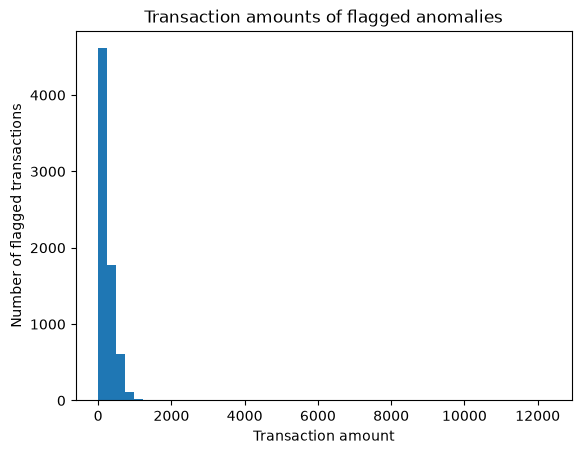

In [25]:
plt.hist(predicted_anomalies['transaction_amount'].dropna(), bins = 50)
plt.xlabel('Transaction amount')
plt.ylabel('Number of flagged transactions')
plt.title('Transaction amounts of flagged anomalies')
plt.show()

**Reading the histogram.** Most flagged transactions have ordinary amounts, below about 1,000, and only a handful sit in the extreme tail. So the model is not just flagging large transactions. The amount tail contributes, but most flags are driven by other features, mainly the rare category values shown in the profile above. Large amounts on their own would not be a good fraud rule either, because in this data fraud risk depends on several features together.

Fraud Rate among anomalies

In [26]:
#high values -> anomalies contain many frauds; low value -> anomalies are mostly noise
fraud_rate_in_anomalies = y[binary_preds == 1].mean()
fraud_rate_in_anomalies

np.float64(0.06213333333333333)

**Fraud rate among anomalies.** 6.2% of flagged transactions are fraud, against a 1.5% base rate: about a **4x lift**. So the anomaly score does carry some fraud signal, and flagged transactions are much more likely to be fraud than a random sample. But 4x enrichment at 6% precision is far too weak to act on by itself.

#### 4. Signal ceiling check: is it the model or the data?

In [27]:
# --- Signal ceiling check ---------------------------------------------------
# IsolationForest is unsupervised, so a weak score is ambiguous: it could mean
# "wrong model" or "no signal in the features". Since we have labels, we can
# check the ceiling by letting a supervised model use them directly.
# If even a supervised model can't separate fraud, the features carry no fraud
# signal and no anomaly method will either.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

X_sup = pd.get_dummies(df.drop(columns='is_fraud'), columns=['device_type'])
y_sup = df['is_fraud']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sup, y_sup, test_size=0.3, random_state=0, stratify=y_sup
)

clf = HistGradientBoostingClassifier(random_state=0)
clf.fit(X_tr, y_tr)
p_te = clf.predict_proba(X_te)[:, 1]

print("Supervised gradient boosting (uses the labels directly):")
print("  ROC-AUC:", round(roc_auc_score(y_te, p_te), 4))
print("  Average Precision:", round(average_precision_score(y_te, p_te), 4),
      " (fraud base rate:", round(y_sup.mean(), 4), ")")

Supervised gradient boosting (uses the labels directly):
  ROC-AUC: 0.8625


  Average Precision: 0.1515  (fraud base rate: 0.015 )


**Reading the signal ceiling check.** A supervised model trained on the labels reaches ROC-AUC 0.86 and AP 0.15, which is **10x the base rate and about 4.5x IsolationForest's AP**. So the weak IsolationForest result is a **model limitation, not a data limitation**: the fraud signal exists and is learnable, but much of it is not in the sparse, isolated regions that IsolationForest looks for.

Two caveats. The labels here are synthetic and generated from these features, so the ceiling is higher than it would be on real data. And this check uses a random split rather than a time-based one.

## Conclusion

**Summary.** When fraud labels are available, IsolationForest should not be the primary fraud model. On this data it is better than random (AP 2.2x the base rate) but far weaker than a supervised model (AP 10x the base rate). The main reason is that it flags transactions that are *rare*, not transactions that are *risky*. Its best role is as one extra feature in a supervised model.

### Results

| Model | Average Precision (primary) | Lift over base rate (0.015) | ROC-AUC (secondary) | At the `contamination` threshold |
|---|---|---|---|---|
| Supervised gradient boosting (signal ceiling) | **0.15** | **10x** | 0.86 | not applicable |
| IsolationForest | 0.034 | 2.2x | 0.68 | precision 6.2%, recall 6.2%, ~15 false alerts per fraud caught |

AP is the primary metric because only 1.5% of transactions are fraud. Accuracy (97%) and ROC-AUC flatter weak models on imbalanced data.

### Key findings

**1. The original pipeline was broken in two ways, and both were diagnosed and fixed.**
- **`contamination = 0.5` was a bug.** It forced IsolationForest to flag half of all transactions, which produced ~0.50 accuracy and ~0.02 fraud precision: a coin flip, not a model. `contamination` only sets the `.predict()` threshold, not the scores. It is now set to the true fraud rate (0.015).
- **The first dataset had no learnable signal.** `is_fraud` was drawn independently of every feature, and a supervised model with direct access to the labels scored ROC-AUC ≈ 0.49. The lesson: **check that the signal exists before blaming the model.** `generate_data.py` now generates labels from a logistic risk model.

**2. No threshold rescues IsolationForest.** The precision–recall curve shows that the `contamination` threshold (red dot) is not the problem. Precision is above 10% only at very low recall (about the first 2% of fraud caught), then falls to a few percent and approaches the base rate as recall increases.

**3. IsolationForest flags rare transactions, not risky ones.** Desktop transactions are 5% of the data but 76% of flagged transactions (15x over-represented), while amount and distance are only ~2x higher. Rare one-hot category values isolate a row in a single split, so ordinary desktop transactions look anomalous.

**4. The model, not the data, is the bottleneck.** A supervised model on the same features reaches AP 0.15, about 4.5x IsolationForest. Much of the fraud signal (young accounts, night-time activity, short transaction history) sits in dense, ordinary-looking regions that isolation cannot reach.

### Limitations

- **Synthetic, planted labels.** Labels come from a known function of the features, so the supervised ceiling is higher than it would be on real data. These results show method, not real-world fraud patterns.
- **In-sample IsolationForest metrics.** The model is fitted and scored on the same rows.
- **Random train/test split** for the supervised check. Fraud models should be validated on a later time period.
- **No cost view.** Results are reported as rates, not as fraud value caught versus analyst workload.

### Recommendations (applied in Part 2 on real data)

- **Supervised model first** (gradient boosting / LightGBM), with class weights for the imbalance. Validation and test sets keep the real fraud rate, with no resampling.
- **IsolationForest score as an extra feature**, fitted on the training period only, and with low-cardinality categoricals left out so rarity alone doesn't drive the score.
- **Time-based split**, so the model is evaluated on future transactions.
- **Threshold set by cost**: fraud value caught versus alerts per 1,000 transactions, not by `contamination`.
- **Drift monitoring** (PSI) on features and model score over time.
